In [17]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow.keras import layers
import pathlib  # 객체지향 방식으로 파일 경로를 다룸
import urllib.request # url을 통해 파일 다운로드 기능 제공
import tarfile

def get_dataset_path():
    # 현재 실행 중인 파이썬 파일(또는 주피터 노트북)의 위치를 기준으로 경로 설정
    # 만약 절대 경로를 쓰고 싶다면 r"C:\Users\...\aircraftdatasets\4000pcs" 처럼 직접 입력하셔도 됩니다.
    dataset_dir = os.path.join(os.getcwd(), 'aircraftdatasets', '4000pcs')

    # 해당 경로가 실제로 존재하는지 검증
    if not os.path.exists(dataset_dir):
        raise FileNotFoundError(f"경로를 찾을 수 없습니다: {dataset_dir}\n"
                                "파이썬 실행 위치와 aircraftdatasets 폴더 위치를 확인해주세요.")
    
    print(f"✅ 데이터셋 경로 연결 완료: {dataset_dir}")
    return dataset_dir

# 경로 변수 할당
data_dir = get_dataset_path()

✅ 데이터셋 경로 연결 완료: c:\Users\human-31\project\ydataprofiling\aircraftdatasets\4000pcs


In [ ]:
if data_dir:
    class_names = ['crack', 'dent', 'missing-head', 'paint-off', 'scratch']
    
    print("\n--- 클래스별 데이터 개수 확인 ---")
    total_images = 0
    for cls in class_names:
        cls_path = os.path.join(data_dir, cls)
        
        # 해당 폴더 내의 모든 파일 개수 카운트
        if os.path.exists(cls_path):
            images = glob.glob(os.path.join(cls_path, '*.*'))
            count = len(images)
            total_images += count
            print(f"[{cls}]: {count}장")
        else:
            print(f"[{cls}]: ⚠️ 폴더를 찾을 수 없습니다.")
            
    print(f"---------------------------------")
    print(f"총 데이터 개수: {total_images}장")


--- 클래스별 데이터 개수 확인 ---
[crack]: 996장
[dent]: 1346장
[missing-head]: 928장
[paint-off]: 789장
[scratch]: 222장
---------------------------------
총 데이터 개수: 4281장


In [19]:
# 데이터 다운로드 및 경로 설정
data_dir = get_dataset_path()  # 함수호출
data_dir = pathlib.Path(data_dir)

✅ 데이터셋 경로 연결 완료: c:\Users\human-31\project\ydataprofiling\aircraftdatasets\4000pcs


In [20]:
classes = sorted([item.name for item in data_dir.glob('*/') if item.is_dir()])  # 리스트 컴프리헨션을 사용하여 각 디렉터리의 이름(예: 'daisy', 'dandelion' 등)만 추출
image_count = len(list(data_dir.glob('*/*.jpg')))
print(f"발견된 클래스: {classes}")
print(f"총 이미지 개수: {image_count}")

발견된 클래스: ['crack', 'dent', 'missing-head', 'paint-off', 'scratch']
총 이미지 개수: 4281


In [21]:
for class_name in classes:
    class_images = len(list(data_dir.glob(f'{class_name}/*')))
    print(f"{class_name}: {class_images}개 이미지")

crack: 996개 이미지
dent: 1346개 이미지
missing-head: 928개 이미지
paint-off: 789개 이미지
scratch: 222개 이미지


In [22]:
img_height = 180
img_width = 180
batch_size = 32

In [23]:
# 1. 데이터셋 로드 (Training)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(data_dir),
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 2. 데이터셋 로드 (Validation)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(data_dir),
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 3. 클래스 이름 및 개수 파악
class_names = train_ds.class_names
print(f"클래스 목록: {class_names}")

# 직접 입력하신 개수를 기반으로 가중치 계산
# 순서: crack, dent, missing-head, paint-off, scratch
counts = [996, 1346, 928, 789, 222]
total = sum(counts)
num_classes = len(counts)

# 클래스별 가중치 산출 (전체 / (클래스수 * 개별수))
class_weights = {i: total / (num_classes * count) for i, count in enumerate(counts)}

print("계산된 클래스 가중치:", class_weights)

Found 4281 files belonging to 5 classes.
Using 3425 files for training.
Found 4281 files belonging to 5 classes.
Using 856 files for validation.
클래스 목록: ['crack', 'dent', 'missing-head', 'paint-off', 'scratch']
계산된 클래스 가중치: {0: 0.8596385542168675, 1: 0.6361069836552748, 2: 0.9226293103448275, 3: 1.0851711026615969, 4: 3.8567567567567567}


In [ ]:
# 1. 베이스 모델 설정
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

# 2. 파인 튜닝 설정
base_model.trainable = True
for layer in base_model.layers[:-20]: # 상위 20개 레이어만 학습
    layer.trainable = False

# 3. 모델 통합
model = tf.keras.Sequential([
    # 증강 레이어
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    
    # MobileNetV2 전처리
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input, 
                  input_shape=(img_height, img_width, 3)),
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    # 분류기
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# 4. 컴파일
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # 0.001보다 낮게 설정
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. 학습
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights 
)

C:\Users\human-31\AppData\Local\Temp\ipykernel_26104\4161291597.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Epoch 1/20


c:\Users\human-31\project\ydataprofiling\.venv\lib\site-packages\keras\src\layers\core\lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



108/108 ━━━━━━━━━━━━━━━━━━━━ 69s 572ms/step - accuracy: 0.6636 - loss: 0.9056 - val_accuracy: 0.6974 - val_loss: 0.9531
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 58s 534ms/step - accuracy: 0.8219 - loss: 0.4618 - val_accuracy: 0.7862 - val_loss: 0.7229
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 59s 543ms/step - accuracy: 0.8730 - loss: 0.3568 - val_accuracy: 0.8236 - val_loss: 0.5609
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 57s 524ms/step - accuracy: 0.8958 - loss: 0.2804 - val_accuracy: 0.8621 - val_loss: 0.4663
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 56s 521ms/step - accuracy: 0.8972 - loss: 0.2659 - val_accuracy: 0.8703 - val_loss: 0.4450
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 57s 523ms/step - accuracy: 0.9235 - loss: 0.2115 - val_accuracy: 0.8843 - val_loss: 0.3898
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 57s 526ms/step - accuracy: 0.9215 - loss: 0.2174 - val_accuracy: 0.8738 - val_loss: 0.4353
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 59s 546ms/step - accuracy: 0.9404 - loss: 0.1703 - va

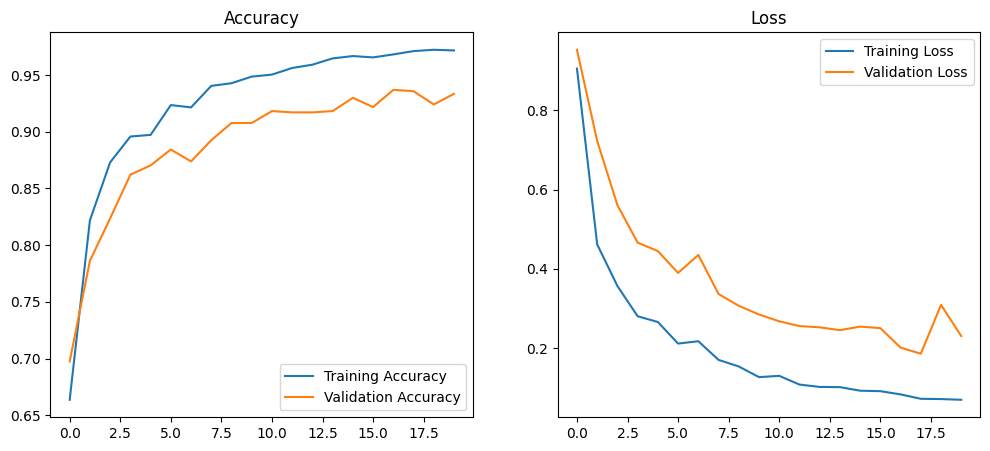

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

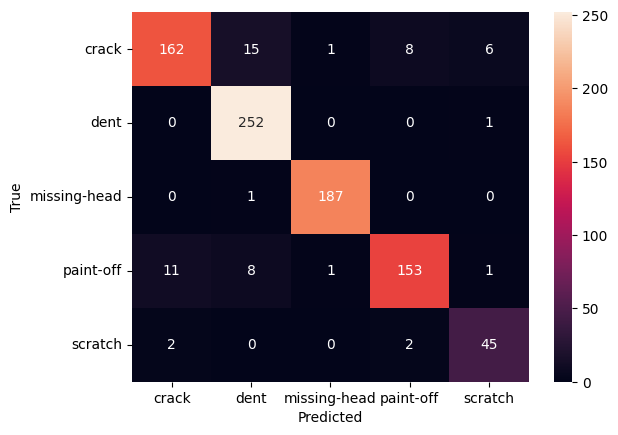

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 예측값 생성
y_pred = []
y_true = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# 리포트 출력
print(classification_report(y_true, y_pred, target_names=class_names))

# 히트맵 시각화
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
model.save('aircraft_defect_model_v1.h5')
print("✅ 모델 저장 완료!")

✅ 모델 저장 완료!


검증 데이터셋에 대한 예측을 진행 중입니다... (시간이 소요될 수 있습니다)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━

c:\Users\human-31\project\ydataprofiling\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-31\project\ydataprofiling\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-31\project\ydataprofiling\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-31\project\ydataprofiling\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\human-31\project\ydataprofiling\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserW

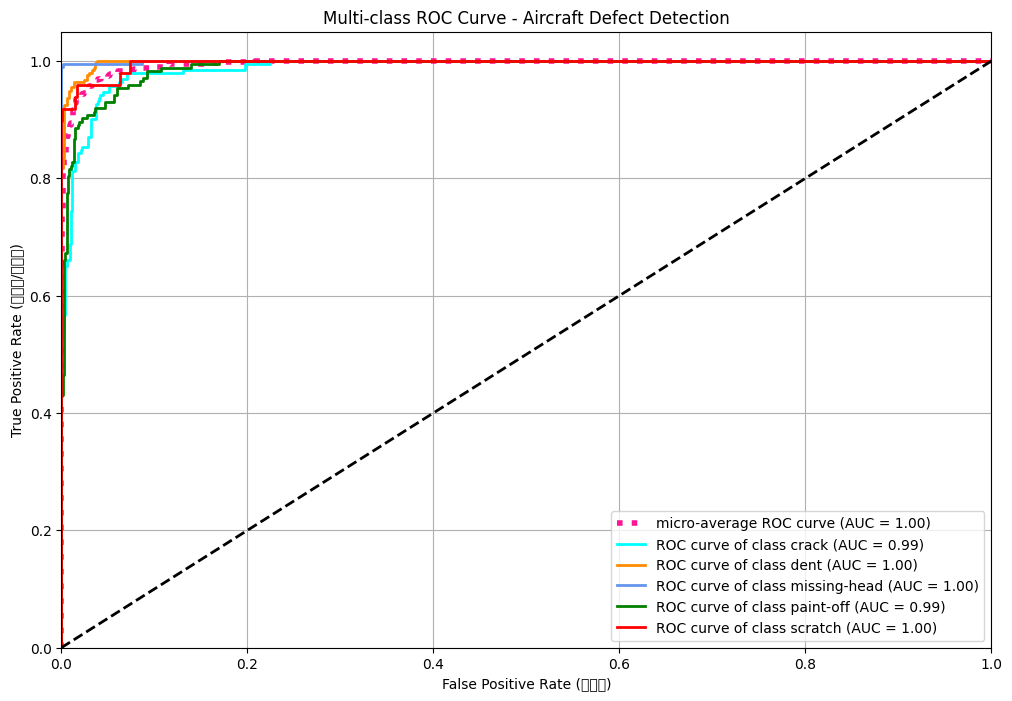

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import numpy as np

# --- 1. 데이터 준비 및 예측 ---
# 검증 데이터셋(val_ds)에서 이미지와 라벨을 추출합니다.
# 주의: val_ds가 shuffle되어 있지 않아야 정확한 비교가 가능합니다.
y_test = []
y_score = []

print("검증 데이터셋에 대한 예측을 진행 중입니다... (시간이 소요될 수 있습니다)")
for images, labels in val_ds:
    # 모델 예측 (확률값 추출)
    preds = model.predict(images)
    
    y_test.extend(labels.numpy())
    y_score.extend(preds)

y_test = np.array(y_test)
y_score = np.array(y_score)
n_classes = len(class_names)

# --- 2. 라벨 이진화 (One-Hot Encoding) ---
# ROC 곡선 계산을 위해 라벨을 이진화합니다. (예: 2 -> [0, 0, 1, 0, 0])
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# --- 3. 클래스별 ROC 및 AUC 계산 ---
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- 4. Micro-average ROC 및 AUC 계산 (전체적인 성능) ---
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# --- 5. ROC 곡선 시각화 ---
plt.figure(figsize=(12, 8))

# Micro-average ROC 곡선 (점선)
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average ROC curve (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

# 클래스별 ROC 곡선 (실선)
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

# 대각선 (무작위 예측)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# 그래프 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve - Aircraft Defect Detection')
plt.legend(loc="lower right")
plt.grid(True)

# 그래프 출력
# st.pyplot(plt) # Streamlit 환경인 경우
plt.show() # 로컬 주피터 노트북 환경인 경우